In [5]:
import numpy as np
import matplotlib.pyplot as plt



In [6]:
def steady_state_profile(x: np.ndarray, D: float, r: float, c0: float, L: float) -> np.ndarray:
    """Exact steady-state solution: D*c'' - r*c = 0, c(0)=c0, c'(L)=0.

    c_ss(x) = c0 * cosh((L - x) / lambda) / cosh(L / lambda),  lambda = sqrt(D / r)

    `lambda` is the characteristic penetration depth (same quantity as in
    Thurber's antibody-penetration analysis).
    """
    lam = np.sqrt(D / r)
    return c0 * np.cosh((L - x) / lam) / np.cosh(L / lam)

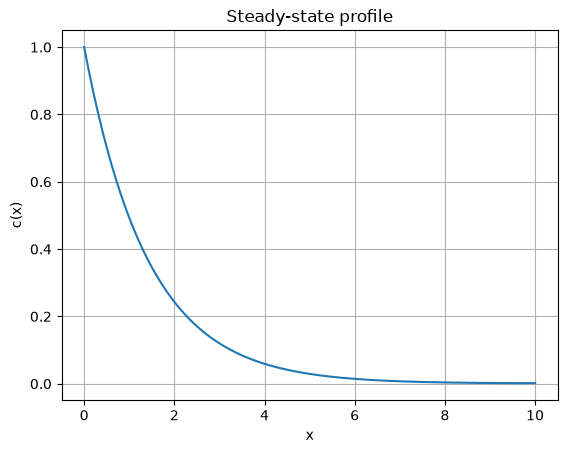

In [7]:
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
c = steady_state_profile(x, D=1.0, r=0.5, c0=1.0, L=10.0)

plt.plot(x, c)
plt.xlabel("x")
plt.ylabel("c(x)")
plt.title("Steady-state profile")
plt.grid(True)
plt.show()

## Dataset visualization

Explore `outputs/dataset.npz` (generated by `generate_data.py`): how `C(x,t)` depends on `c0`, `D`, `r`, and `t`. Each "condition" (one `(c0, D, r)` triple) contributes `n_times` consecutive rows in `X`/`Y` — one profile per sampled time point.

In [ ]:
data = np.load("../outputs/dataset.npz")
X, Y, x_grid, t_points = data["X"], data["Y"], data["x_grid"], data["t_points"]
L = float(data["L"])

n_times = len(t_points)
n_conditions = X.shape[0] // n_times

# generate_data.py writes rows condition-major (all n_times rows for condition 0,
# then condition 1, ...), so this reshape recovers a clean (condition, time, ...) view.
Xc = X.reshape(n_conditions, n_times, 4)
Yc = Y.reshape(n_conditions, n_times, x_grid.size)

print(f"{n_conditions} conditions x {n_times} time points, grid of {x_grid.size} points, L={L} um")
print("c0 range:", data["c0_range"], " D range (um^2/s):", data["D_range"], " r range (1/s):", data["r_range"])
print("t_points (s):", t_points)

### Time evolution for a few random conditions

For each sampled `(c0, D, r)`, plot all `n_times` profiles together to see the transient approaching steady state (cf. Step 8 of `docs/ANALYTICAL_SOLVER_MATH.md`).

In [ ]:
rng = np.random.default_rng(0)
cond_idx = rng.choice(n_conditions, size=4, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, ci in zip(axes, cond_idx):
    log_c0, log_D, log_r, _ = Xc[ci, 0]
    for j in range(n_times):
        ax.plot(x_grid, Yc[ci, j], color=plt.cm.viridis(j / (n_times - 1)),
                 label=f"t={t_points[j]:.1e}s")
    ax.set_title(f"c0=10^{log_c0:.2f}\nD=10^{log_D:.2f}, r=10^{log_r:.2f}", fontsize=9)
    ax.set_xlabel("x (um)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("C(x,t)")
axes[0].legend(fontsize=6, loc="upper right")
fig.suptitle("Time evolution of C(x,t) for 4 random sampled conditions")
fig.tight_layout()
plt.show()

### Isolating the effect of a single parameter

The dataset is sampled log-uniformly at random, not on a grid, so to see the effect of one parameter alone, we hold `c0` and `r` (or `c0` and `D`) within a narrow log-band and vary the third parameter, evaluated at a fixed time point.

In [ ]:
def select_band(fixed_cols, targets, tol=0.4):
    """Indices of conditions whose log10-params in `fixed_cols` are within `tol` of `targets`."""
    mask = np.ones(n_conditions, dtype=bool)
    for col, target in zip(fixed_cols, targets):
        mask &= np.abs(Xc[:, 0, col] - target) < tol
    return np.where(mask)[0]


def plot_param_sweep(vary_col, fixed_cols, targets, t_idx, cmap, title, label_fmt):
    idx = select_band(fixed_cols, targets, tol=0.4)
    if len(idx) == 0:
        print("No conditions found in this band - widen tol.")
        return
    idx = idx[np.argsort(Xc[idx, 0, vary_col])]
    idx = idx[np.linspace(0, len(idx) - 1, min(7, len(idx))).astype(int)]

    vals = Xc[idx, 0, vary_col]
    vmin, vmax = vals.min(), vals.max() + 1e-9

    fig, ax = plt.subplots(figsize=(6.5, 5))
    for ci, v in zip(idx, vals):
        ax.plot(x_grid, Yc[ci, t_idx], color=cmap((v - vmin) / (vmax - vmin)),
                 label=label_fmt(v))
    ax.set_xlabel("x (um)")
    ax.set_ylabel(f"C(x, t={t_points[t_idx]:.1e}s)")
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    plt.show()


t_mid = n_times // 2

# Effect of D: fix c0~10^0, r~10^-4.5, vary D
plot_param_sweep(
    vary_col=1, fixed_cols=[0, 2], targets=[0.0, -4.5], t_idx=t_mid,
    cmap=plt.cm.plasma,
    title="Effect of D (c0~10^0, r~10^-4.5 held ~fixed)",
    label_fmt=lambda v: f"D=10^{v:.2f}",
)

In [ ]:
# Effect of r: fix c0~10^0, D~10^1.4 (mid of [1,50] in log-space), vary r
plot_param_sweep(
    vary_col=2, fixed_cols=[0, 1], targets=[0.0, 1.4], t_idx=t_mid,
    cmap=plt.cm.cividis,
    title="Effect of r (c0~10^0, D~10^1.4 held ~fixed)",
    label_fmt=lambda v: f"r=10^{v:.2f}",
)

# Effect of c0: fix D~10^1.4, r~10^-4.5, vary c0 (should only rescale amplitude,
# not change the shape - the PDE is linear in c0, cf. Step 0 of the math derivation)
plot_param_sweep(
    vary_col=0, fixed_cols=[1, 2], targets=[1.4, -4.5], t_idx=t_mid,
    cmap=plt.cm.cool,
    title="Effect of c0 (D~10^1.4, r~10^-4.5 held ~fixed) - linear rescaling only",
    label_fmt=lambda v: f"c0=10^{v:.2f}",
)

### Validating the penetration-depth scaling across the whole dataset

Step 1 of `docs/ANALYTICAL_SOLVER_MATH.md` predicts a characteristic penetration depth `lambda = sqrt(D/r)`. Check this empirically: at the last (near-steady-state) time point, measure where each profile has dropped to `C(0)/e`, and compare against the theoretical `lambda` across all sampled conditions (restricted to cases where `lambda < L`, i.e. the profile actually decays within the domain).

In [ ]:
last_t = n_times - 1

c0_all = 10 ** Xc[:, 0, 0]
D_all = 10 ** Xc[:, 0, 1]
r_all = 10 ** Xc[:, 0, 2]
lam_theory = np.sqrt(D_all / r_all)

profiles = Yc[:, last_t, :]
target = profiles[:, 0] / np.e
below = profiles <= target[:, None]
has_crossing = below.any(axis=1)
first_idx = np.argmax(below, axis=1)
lam_empirical = np.where(has_crossing, x_grid[first_idx], np.nan)

valid = np.isfinite(lam_empirical) & (lam_theory < L)
print(f"{valid.sum()} / {n_conditions} conditions have lambda < L at t={t_points[last_t]:.1e}s "
      f"(profile decays within the domain, so the C0/e crossing is meaningful)")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(lam_theory[valid], lam_empirical[valid], s=8, alpha=0.3)
lims = [0, min(L, np.nanmax(lam_theory[valid]) * 1.1)]
ax.plot(lims, lims, "r--", lw=1, label="y = x")
ax.set_xlabel(r"theoretical $\lambda = \sqrt{D/r}$ (um)")
ax.set_ylabel(r"empirical penetration depth (um, where $C = C(0)/e$)")
ax.set_title(f"Penetration depth: dataset vs. theory (t={t_points[last_t]:.1e}s)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Space-time diagram of C(x,t)

The dataset only has `n_times=8` sampled time points per condition — fine for training, too coarse for a smooth heatmap. Instead, call `analytical_transient_profile` directly (imported from `solver.py`, not duplicated here) on a fine `(x, t)` grid to get the full continuous field, and plot it as a 2D heatmap: `x` (distance from the vessel) on one axis, `t` on the other, color = concentration.

In [ ]:
import sys
sys.path.insert(0, "../src/diffusion_degradation")
from solver import analytical_transient_profile


def xt_diagram(ax, D, r, c0, L, t_max, nx=150, nt=150, cmap="viridis"):
    """Heatmap of C(x,t) on [0,L] x [0,t_max] using the exact analytical solution.

    n_modes=2000 (not the 150-300 used elsewhere): the near-t=0 corner of a fine
    (x,t) grid is exactly where Step 11 of the math derivation predicts the slowest
    Fourier-series convergence (coefficients decay like O(1/n)), and a low mode count
    leaves a small unphysical negative overshoot there (Gibbs-phenomenon-like). 2000
    modes brings that down to ~1e-3 (numerical noise) and still runs in well under a
    second per panel.
    """
    x = np.linspace(0, L, nx)
    t = np.linspace(0, t_max, nt)
    C = analytical_transient_profile(x, t, D, r, c0, L, n_modes=2000)  # shape (nx, nt)

    im = ax.pcolormesh(t, x, C, shading="auto", cmap=cmap)
    ax.set_xlabel("t (s)")
    ax.set_ylabel("x (um) - distance from vessel")
    return im

In [ ]:
# Three contrasting regimes (cf. Step 1 of docs/ANALYTICAL_SOLVER_MATH.md):
# diffusion-dominated (lambda >> L), balanced (lambda ~ L), reaction-dominated (lambda << L).
cases = [
    ("diffusion-dominated", 50.0, 1e-6),
    ("balanced", 10.0, 1e-4),
    ("reaction-dominated", 1.0, 1e-3),
]
c0_demo = 1.0

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (name, D, r) in zip(axes, cases):
    lam = np.sqrt(D / r)
    k1 = np.pi / (2 * L)
    mu1 = D * k1 ** 2 + r
    t_max = 5.0 / mu1  # ~99.3% decay of the slowest (n=1) mode - reaches near-steady-state

    im = xt_diagram(ax, D, r, c0_demo, L, t_max)
    ax.set_title(f"{name}\nD={D}, r={r:.0e}, lambda={lam:.0f} um")
    fig.colorbar(im, ax=ax, label="C(x,t)")

fig.suptitle(f"Space-time diagrams of C(x,t) for contrasting D, r regimes (c0={c0_demo}, L={L} um)")
fig.tight_layout()
plt.show()